Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../results', exist_ok=True)
print("Library siap!")

Library siap!


 Load Dataset Bersih

In [2]:
df = pd.read_csv('../data/dataset_bersih.csv')
print("Shape:", df.shape)
df.head()

Shape: (4931, 6)


,tahun,bulan,minggu,kategori,jumlah_order,kategori_encoded
0,2016,9,37,health_beauty,3,43
1,2016,10,40,air_conditioning,8,1
2,2016,10,40,audio,1,4
3,2016,10,40,auto,7,5
4,2016,10,40,baby,11,6


 Persiapan Fitur & Target

In [5]:
# Fitur input (X) dan target (y)
df['kuartal'] = df['bulan'].apply(lambda x: (x - 1) // 3 + 1)  # membuat kolom kuartal dari bulan

fitur = ['tahun', 'bulan', 'minggu', 'kuartal', 'kategori_encoded']
target = 'jumlah_order'

X = df[fitur]
y = df[target]

# Split data 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (3944, 5)
Test: (987, 5)


Fungsi Evaluasi

In [6]:
def evaluasi(nama_model, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    
    print(f"\n{'='*35}")
    print(f"  {nama_model}")
    print(f"{'='*35}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    
    return {'Model': nama_model, 'RMSE': round(rmse,4), 
            'MAE': round(mae,4), 'MAPE': round(mape,2)}

Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

hasil_lr = evaluasi("Linear Regression", y_test, y_pred_lr)


  Linear Regression
  RMSE : 40.5977
  MAE  : 24.7790
  MAPE : 563.95%


Random Forest

In [8]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

hasil_rf = evaluasi("Random Forest", y_test, y_pred_rf)


  Random Forest
  RMSE : 23.6365
  MAE  : 10.8054
  MAPE : 113.35%


Feature Importance Random Forest

=== Feature Importance Random Forest ===
              Fitur  Importance
4  kategori_encoded    0.584097
2            minggu    0.229606
0             tahun    0.122727
1             bulan    0.052647
3           kuartal    0.010923


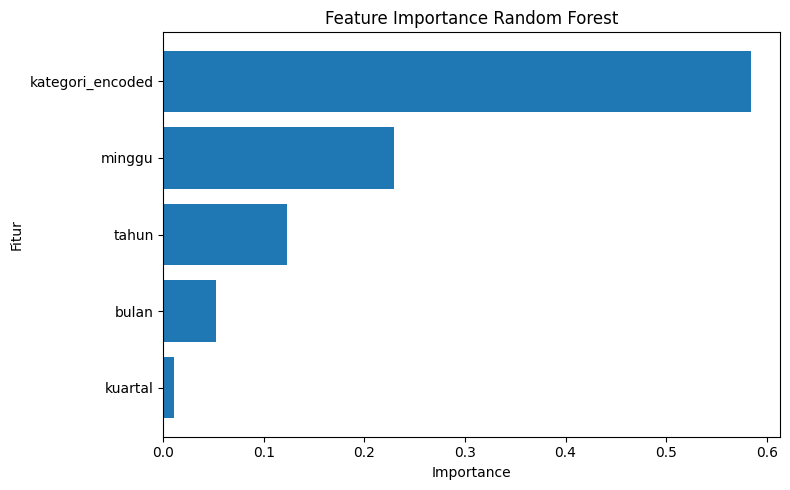

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

print("=== Feature Importance Random Forest ===")
print(rf_importance)

plt.figure(figsize=(8,5))

plt.barh(
    rf_importance['Fitur'],
    rf_importance['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance Random Forest')
plt.xlabel('Importance')
plt.ylabel('Fitur')

plt.tight_layout()

plt.savefig('../results/feature_importance_rf.png')

plt.show()

XGBoost

In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

hasil_xgb = evaluasi("XGBoost", y_test, y_pred_xgb)


  XGBoost
  RMSE : 22.4642
  MAE  : 10.9228
  MAPE : 194.03%


Feature Importance XGBoost

              Fitur  Importance
4  kategori_encoded    0.469688
0             tahun    0.307613
2            minggu    0.111804
1             bulan    0.110895
3           kuartal    0.000000


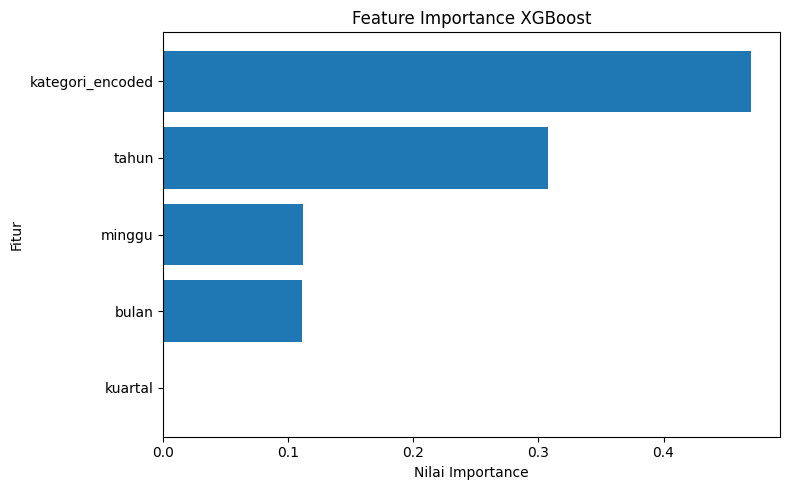

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    'Fitur': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Fitur'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance XGBoost')
plt.xlabel('Nilai Importance')
plt.ylabel('Fitur')

plt.tight_layout()

plt.savefig('../results/feature_importance_xgb.png')

plt.show()

Actual vs Predicted XGBoost

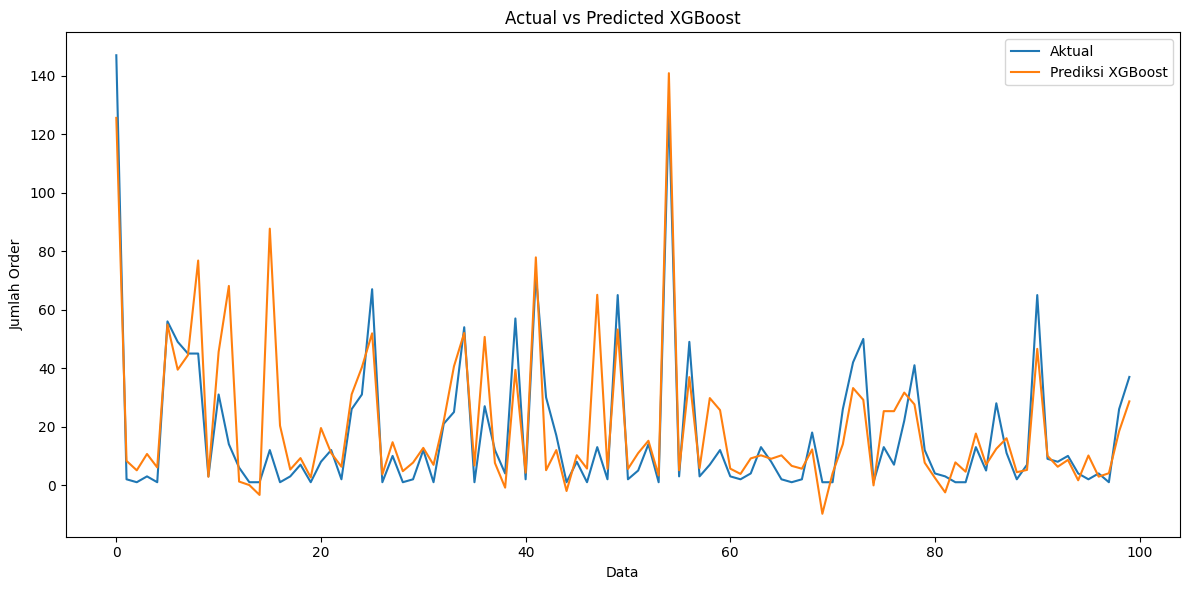

In [14]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:100],
    label='Aktual'
)

plt.plot(
    y_pred_xgb[:100],
    label='Prediksi XGBoost'
)

plt.title('Actual vs Predicted XGBoost')
plt.xlabel('Data')
plt.ylabel('Jumlah Order')

plt.legend()

plt.tight_layout()

plt.savefig('../results/actual_vs_predicted_xgb.png')

plt.show()

Scatter Plot

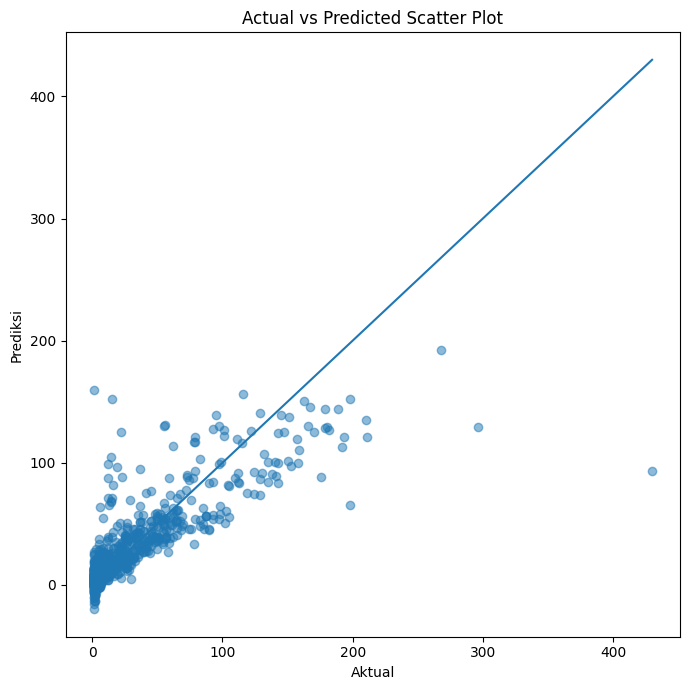

In [15]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred_xgb,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title('Actual vs Predicted Scatter Plot')
plt.xlabel('Aktual')
plt.ylabel('Prediksi')

plt.tight_layout()

plt.savefig('../results/scatter_xgb.png')

plt.show()

Distribusi Error

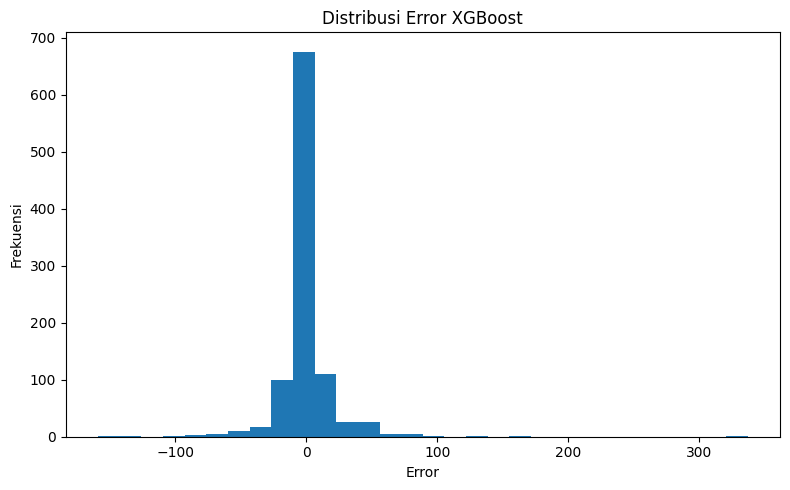

In [16]:
error = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.hist(
    error,
    bins=30
)

plt.title('Distribusi Error XGBoost')
plt.xlabel('Error')
plt.ylabel('Frekuensi')

plt.tight_layout()

plt.savefig('../results/error_distribution_xgb.png')

plt.show()

Tabel Perbandingan Feature Importance RF vs XGBoost

In [19]:
comparison_importance = pd.DataFrame({
    'Fitur': X_train.columns,
    'Random Forest': rf.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})

comparison_importance = comparison_importance.sort_values(
    by='XGBoost',
    ascending=False
)

print("=== Perbandingan Feature Importance ===")
print(comparison_importance)

comparison_importance.to_csv(
    '../results/perbandingan_feature_importance.csv',
    index=False
)

=== Perbandingan Feature Importance ===
              Fitur  Random Forest   XGBoost
4  kategori_encoded       0.584097  0.469688
0             tahun       0.122727  0.307613
2            minggu       0.229606  0.111804
1             bulan       0.052647  0.110895
3           kuartal       0.010923  0.000000


Grafik Perbandingan Feature Importance RF vs XGBoost

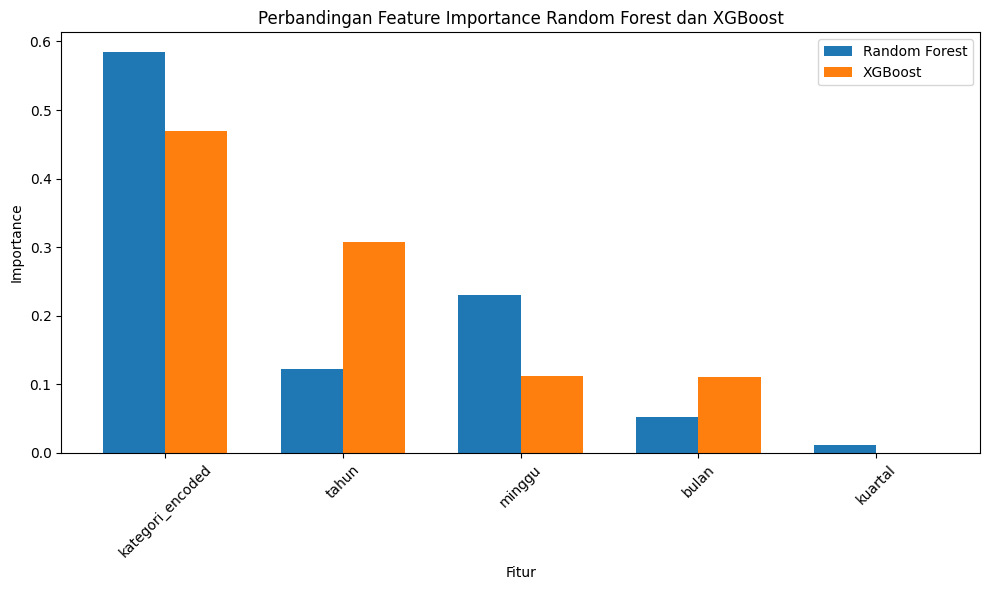

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(comparison_importance))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(
    x - width/2,
    comparison_importance['Random Forest'],
    width,
    label='Random Forest'
)

plt.bar(
    x + width/2,
    comparison_importance['XGBoost'],
    width,
    label='XGBoost'
)

plt.xticks(
    x,
    comparison_importance['Fitur'],
    rotation=45
)

plt.xlabel('Fitur')
plt.ylabel('Importance')
plt.title('Perbandingan Feature Importance Random Forest dan XGBoost')

plt.legend()

plt.tight_layout()

plt.savefig(
    '../results/perbandingan_feature_importance.png'
)

plt.show()

LSTM

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))

# Konversi ke tensor
X_train_t = torch.FloatTensor(X_train_scaled).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test_scaled).unsqueeze(1)
y_train_t = torch.FloatTensor(y_train_scaled)

# Arsitektur LSTM
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=5, hidden_size=64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        self.fc = nn.Linear(32, 1)
    
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x = self.fc(x[:, -1, :])
        return x

# Training
model_lstm = LSTMModel()
optimizer  = torch.optim.Adam(model_lstm.parameters(), lr=0.001)
criterion  = nn.MSELoss()

dataset    = TensorDataset(X_train_t, y_train_t)
loader     = DataLoader(dataset, batch_size=32, shuffle=True)

print("Training LSTM...")
for epoch in range(50):
    model_lstm.train()
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        pred = model_lstm(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/50 - Loss: {loss.item():.4f}")

# Prediksi
model_lstm.eval()
with torch.no_grad():
    y_pred_lstm_scaled = model_lstm(X_test_t).numpy()

y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()

hasil_lstm = evaluasi("LSTM", y_test, y_pred_lstm)

Training LSTM...
  Epoch 10/50 - Loss: 0.0046
  Epoch 20/50 - Loss: 0.0029
  Epoch 30/50 - Loss: 0.0049
  Epoch 40/50 - Loss: 0.0016
  Epoch 50/50 - Loss: 0.0062

  LSTM
  RMSE : 39.9342
  MAE  : 23.5997
  MAPE : 512.26%


Tabel Perbandingan Semua Model


PERBANDINGAN MODEL
            Model    RMSE     MAE   MAPE
          XGBoost 22.4642 10.9228 194.03
    Random Forest 23.6365 10.8054 113.35
             LSTM 39.9342 23.5997 512.26
Linear Regression 40.5977 24.7790 563.95


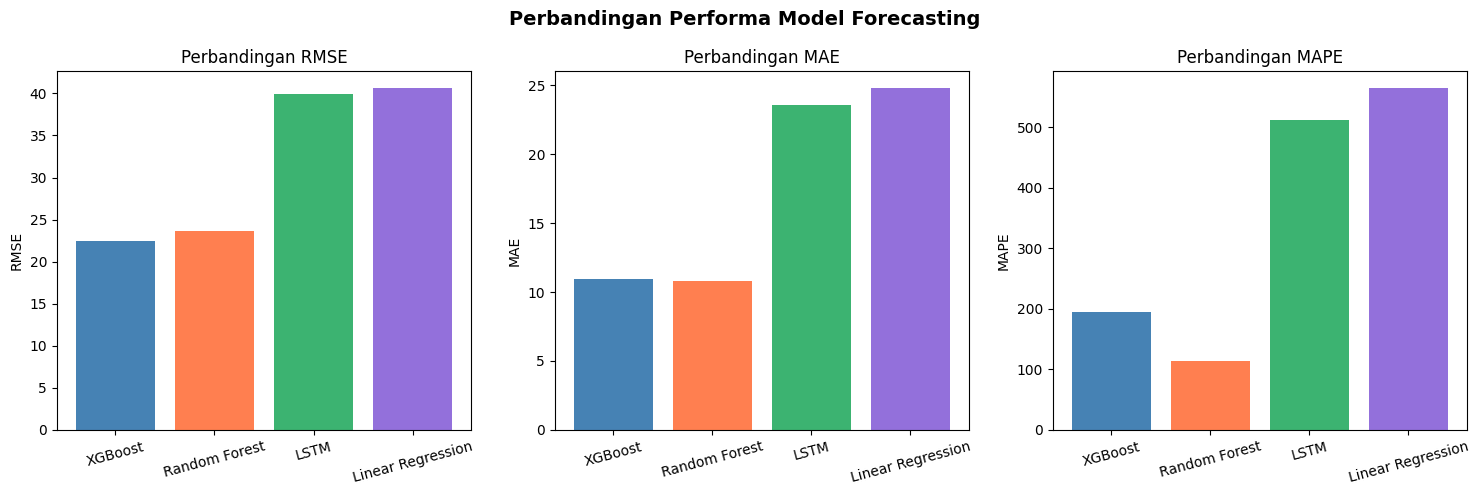

Hasil tersimpan di folder results/


In [12]:
# Gabungkan semua hasil
semua_hasil = pd.DataFrame([hasil_lr, hasil_rf, hasil_xgb, hasil_lstm])
semua_hasil = semua_hasil.sort_values('RMSE')

print("\nPERBANDINGAN MODEL")
print(semua_hasil.to_string(index=False))

# Simpan ke CSV
semua_hasil.to_csv('../results/perbandingan_model.csv', index=False)

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrik = ['RMSE', 'MAE', 'MAPE']
warna  = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for i, m in enumerate(metrik):
    axes[i].bar(semua_hasil['Model'], semua_hasil[m], color=warna)
    axes[i].set_title(f'Perbandingan {m}')
    axes[i].set_ylabel(m)
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Perbandingan Performa Model Forecasting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/perbandingan_model.png', dpi=150)
plt.show()

print("Hasil tersimpan di folder results/")